In [40]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [41]:
df = pd.read_csv("C:/Users/AAGAM DOSHI/Downloads/Unemployment_Rate_upto_11_2020.csv")

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    267 non-null    object 
 1    Date                                     267 non-null    object 
 2    Frequency                                267 non-null    object 
 3    Estimated Unemployment Rate (%)          267 non-null    float64
 4    Estimated Employed                       267 non-null    int64  
 5    Estimated Labour Participation Rate (%)  267 non-null    float64
 6   Region.1                                  267 non-null    object 
 7   longitude                                 267 non-null    float64
 8   latitude                                  267 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 18.9+ KB


In [43]:
df.describe()


,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),longitude,latitude
count,267.000000,2.670000e+02,267.000000,267.000000,267.000000
mean,12.236929,1.396211e+07,41.681573,22.826048,80.532425
std,10.803283,1.336632e+07,7.845419,6.270731,5.831738
min,0.500000,1.175420e+05,16.770000,10.850500,71.192400
25%,4.845000,2.838930e+06,37.265000,18.112400,76.085600
50%,9.650000,9.732417e+06,40.390000,23.610200,79.019300
75%,16.755000,2.187869e+07,44.055000,27.278400,85.279900
max,75.850000,5.943376e+07,69.690000,33.778200,92.937600


In [44]:
df.isnull().sum()

Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Region.1                                    0
longitude                                   0
latitude                                    0
dtype: int64

In [50]:

print(df.isnull().sum())

df.dropna(inplace=True)
df.columns = df.columns.str.strip()

print(df.columns.tolist())
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

print("Shape after cleaning:", df.shape)

Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Region.1                                    0
longitude                                   0
latitude                                    0
dtype: int64
['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Region.1', 'longitude', 'latitude']
Shape after cleaning: (267, 9)


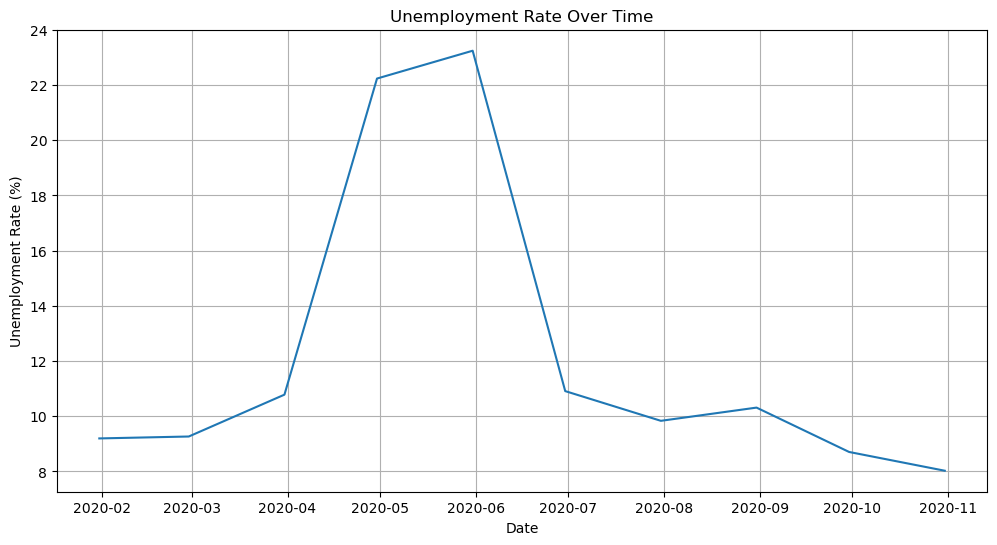

In [54]:
monthly = df.groupby('Date')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(12,6))
plt.plot(monthly.index, monthly.values)
plt.title("Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.grid(True)
plt.show()

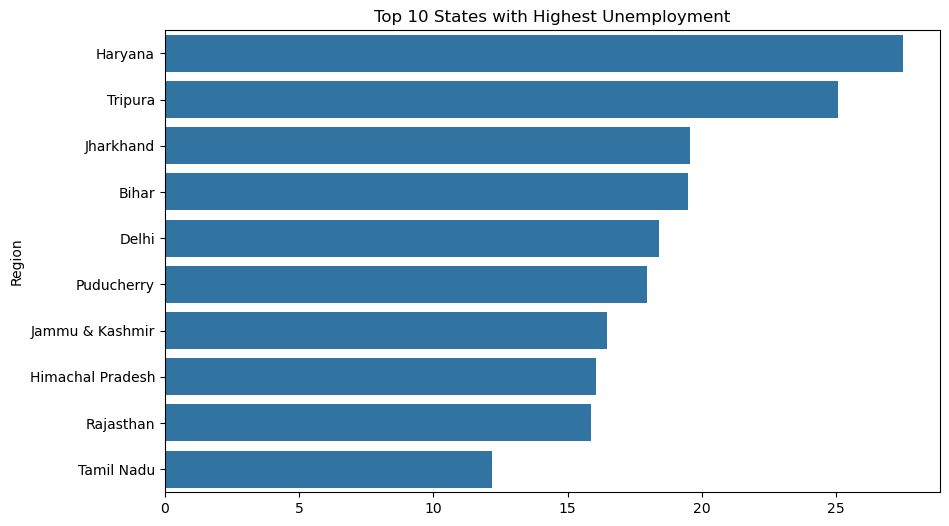

In [56]:
state_avg = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean()

top10 = state_avg.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top10.values, y=top10.index)
plt.title("Top 10 States with Highest Unemployment")
plt.show()

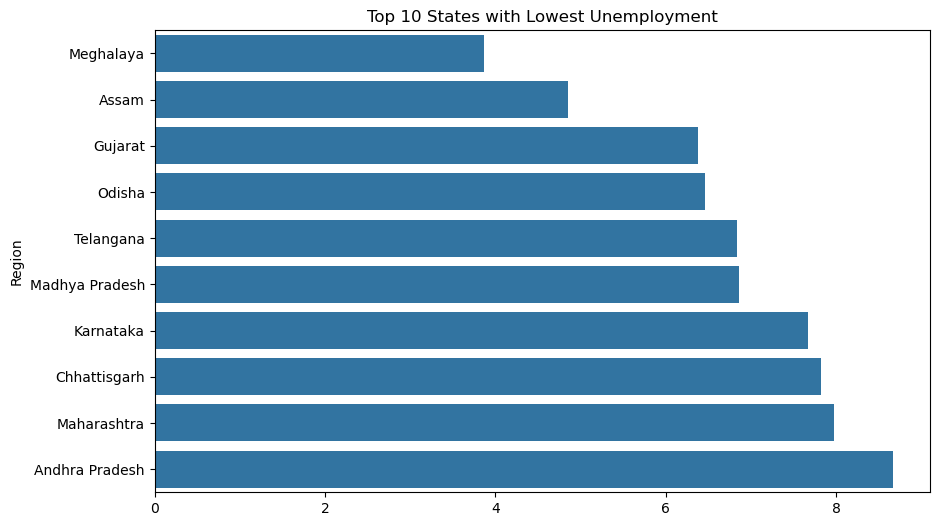

In [58]:
bottom10 = state_avg.sort_values().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=bottom10.values, y=bottom10.index)
plt.title("Top 10 States with Lowest Unemployment")
plt.show()

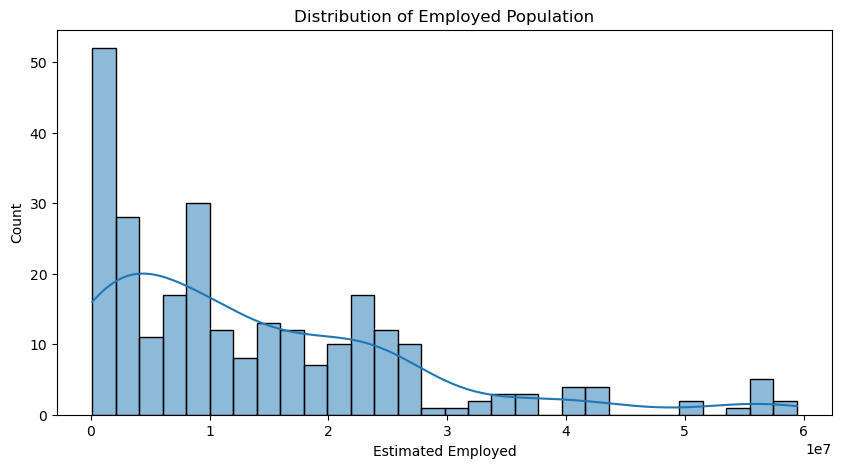

In [60]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['Estimated Employed'],
    bins=30,
    kde=True
)

plt.title("Distribution of Employed Population")
plt.show()

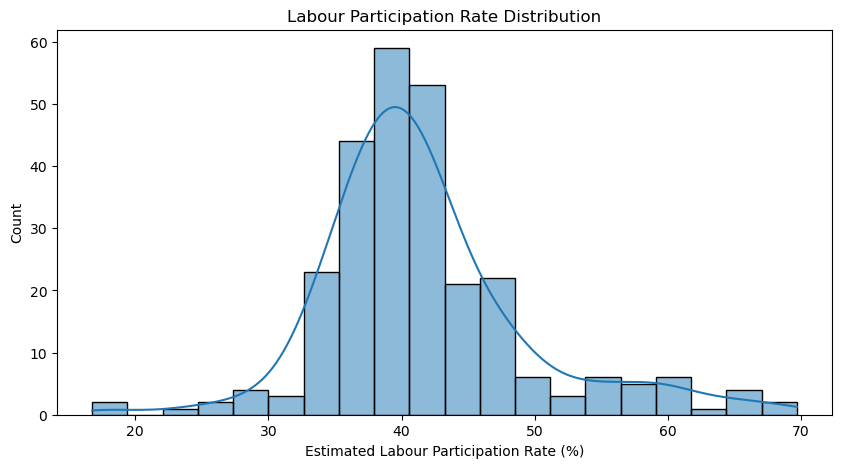

In [62]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['Estimated Labour Participation Rate (%)'],
    bins=20,
    kde=True
)

plt.title("Labour Participation Rate Distribution")
plt.show()

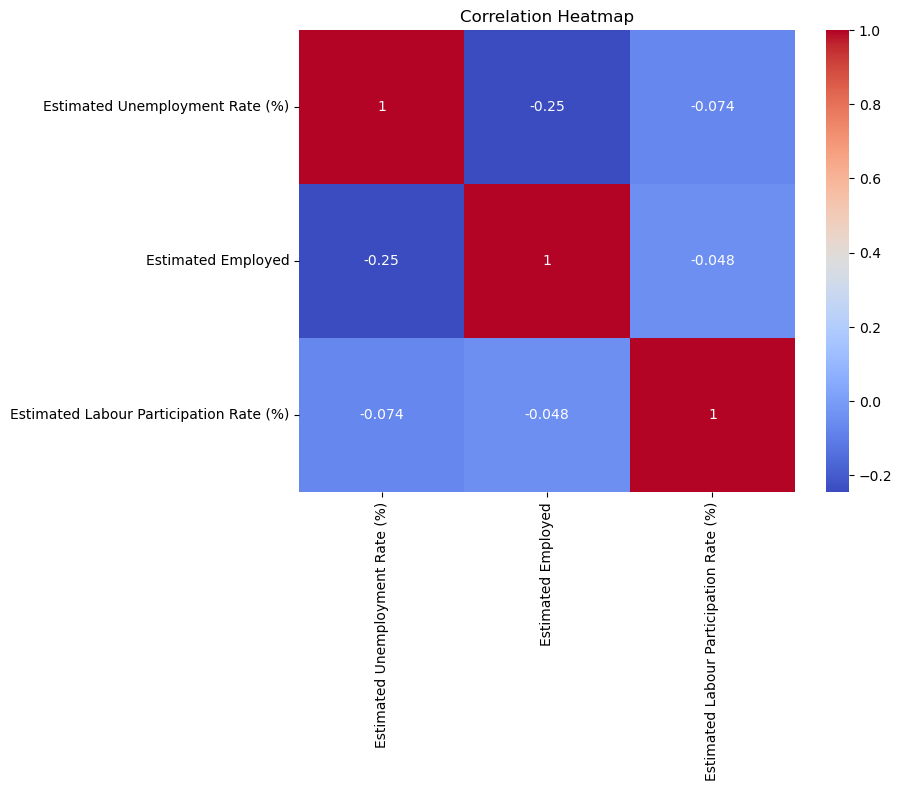

In [64]:
plt.figure(figsize=(8,6))

corr = df[[
    'Estimated Unemployment Rate (%)',
    'Estimated Employed',
    'Estimated Labour Participation Rate (%)'
]].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

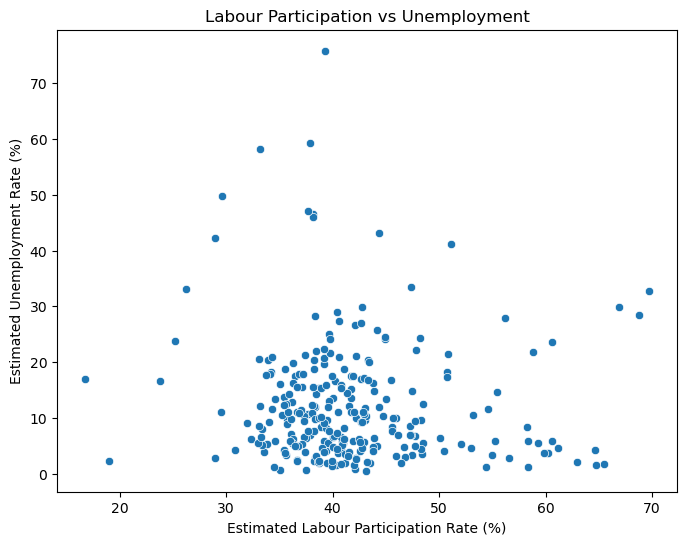

In [66]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Estimated Labour Participation Rate (%)',
    y='Estimated Unemployment Rate (%)',
    data=df
)

plt.title("Labour Participation vs Unemployment")
plt.show()

In [68]:
X = df[[
    'Estimated Employed',
    'Estimated Labour Participation Rate (%)'
]]

y = df['Estimated Unemployment Rate (%)']

In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [72]:
lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("Linear Regression Results")
print("MAE:", mean_absolute_error(y_test, pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_lr)))
print("R2 Score:", r2_score(y_test, pred_lr))

Linear Regression Results
MAE: 7.394932610169026
RMSE: 9.647113879285687
R2 Score: 0.010717169109898061


In [74]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("\nRandom Forest Results")
print("MAE:", mean_absolute_error(y_test, pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_rf)))
print("R2 Score:", r2_score(y_test, pred_rf))


Random Forest Results
MAE: 4.473107407407409
RMSE: 6.613196553161018
R2 Score: 0.535111799871353


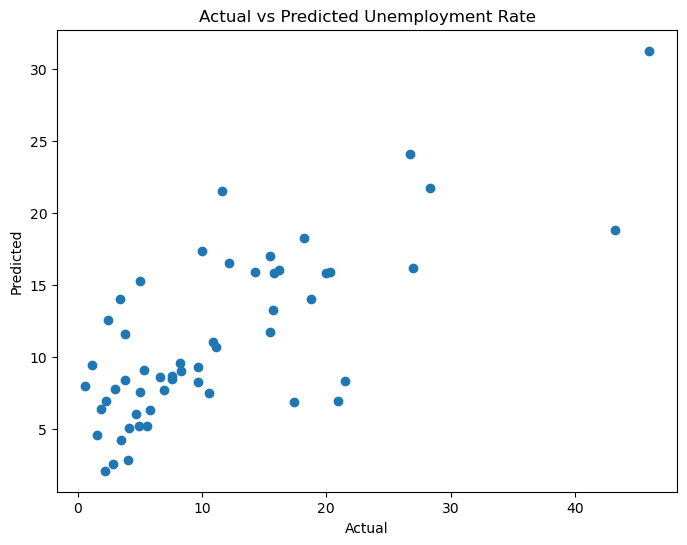

In [76]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, pred_rf)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title("Actual vs Predicted Unemployment Rate")

plt.show()

## Conclusion:

The unemployment dataset was analyzed using Exploratory Data Analysis (EDA) techniques and machine learning models. Various visualizations revealed significant variations in unemployment rates across different states and time periods. The COVID-19 pandemic caused a noticeable increase in unemployment levels after March 2020. Correlation analysis showed relationships between employment, labour participation rate, and unemployment rate. Two machine learning models, Linear Regression and Random Forest Regressor, were trained to predict unemployment rates. The Random Forest model generally achieved better prediction accuracy due to its ability to capture non-linear relationships. This project demonstrates how data science and machine learning can be effectively used to analyze and predict economic indicators such as unemployment.